Files downloaded successfully.
Merged dataset shape: (18248, 101)
Women age 18+ shape: (5837, 101)
Final modeling dataset shape: (2281, 9)
     Age   BMI  Glucose   IncomeRatio AgeGroup BMICategory    GlucoseCategory  \
4   42.0  20.3     84.0  1.230000e+00    40–49      Normal             Normal   
5   72.0  28.6    107.0  2.820000e+00      70+  Overweight  Prediabetes Range   
22  67.0  43.7    130.0  8.900000e-01    60–69       Obese     Diabetes Range   
25  57.0  35.4    398.0  7.700000e-01    50–59       Obese     Diabetes Range   
28  24.0  25.3     95.0  5.397605e-79    18–29  Overweight             Normal   

    RiskScore  Hypertension  
4           1             0  
5           1             0  
22          4             0  
25          4             1  
28          1             0  
Age                0
BMI                0
Glucose            0
IncomeRatio        0
AgeGroup           0
BMICategory        0
GlucoseCategory    0
RiskScore          0
Hypertension       0
dtype

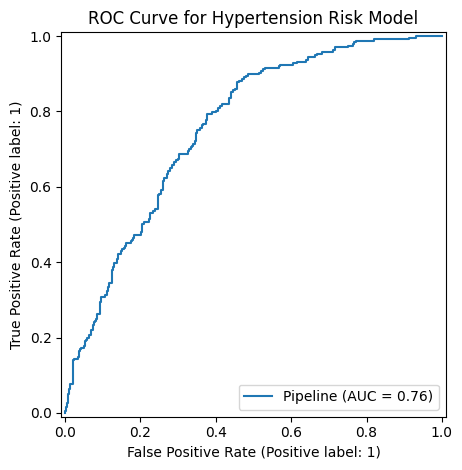

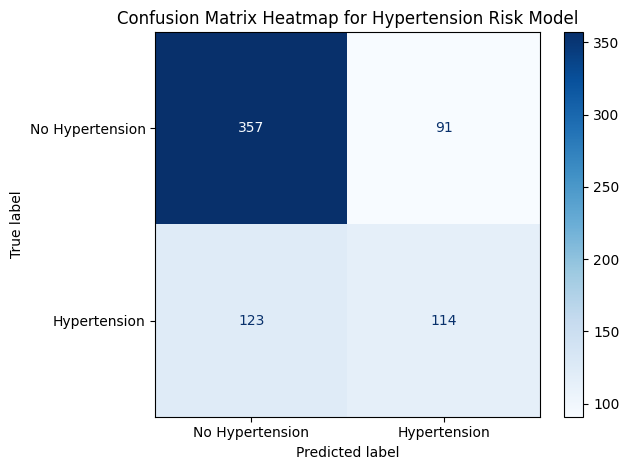

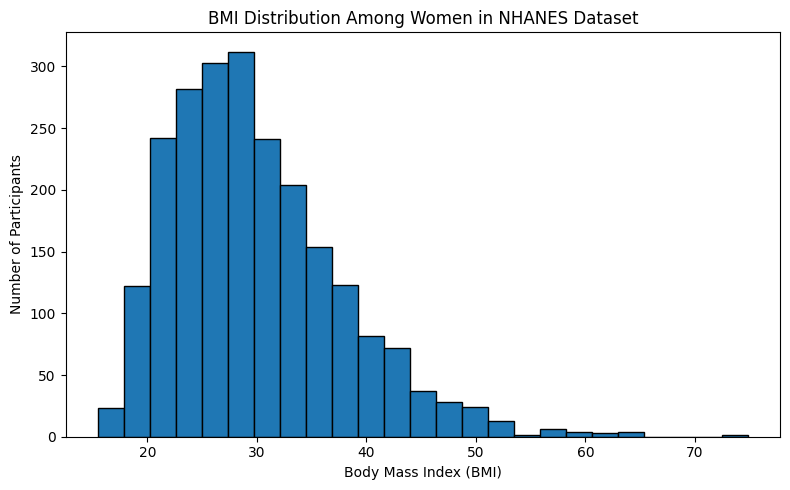

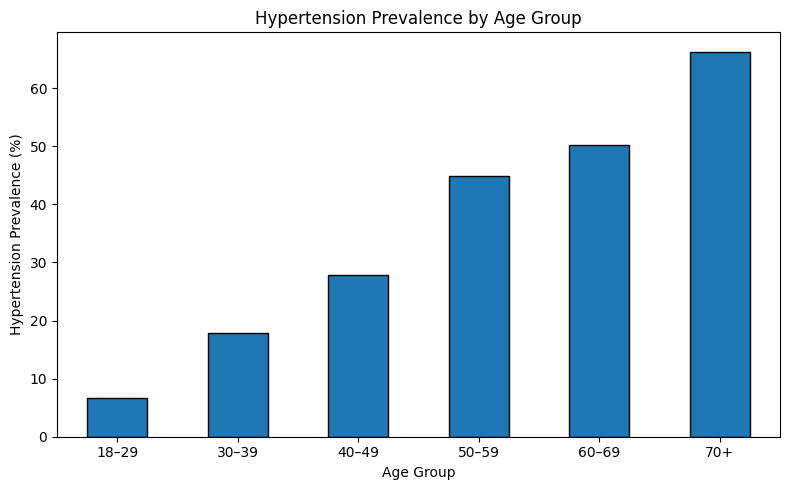

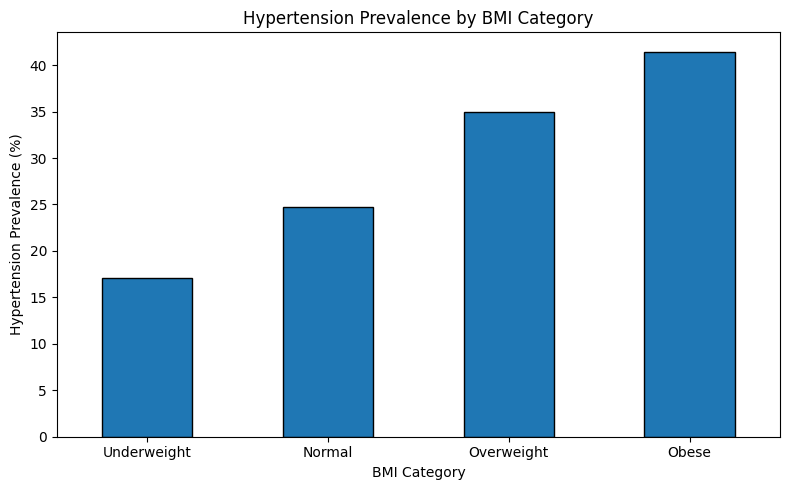

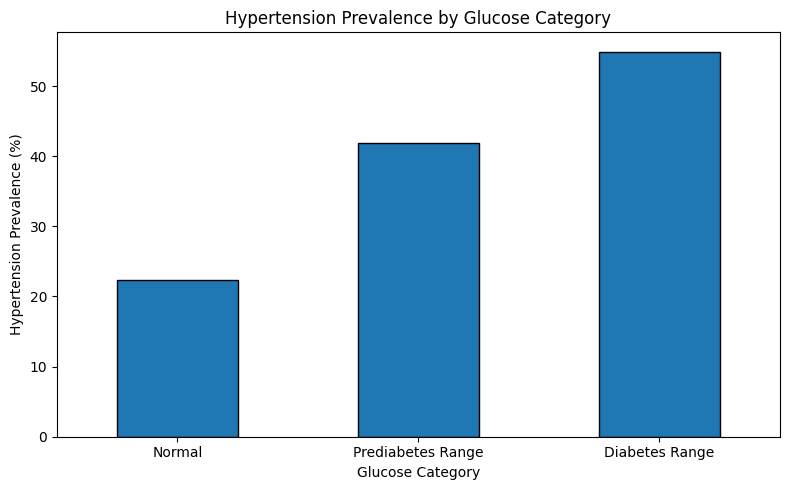

<Figure size 800x500 with 0 Axes>

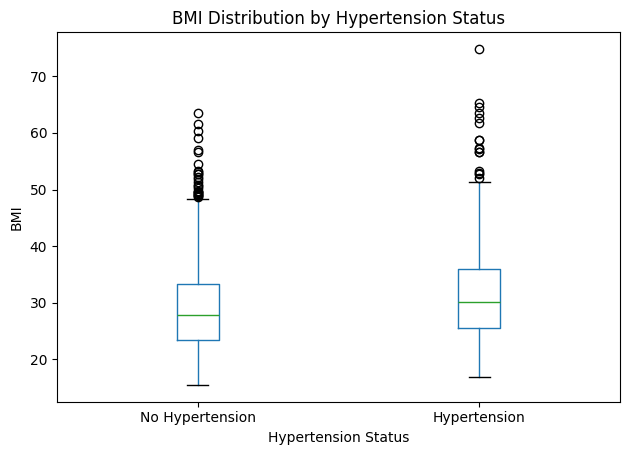

In [3]:
# NHANES Hypertension Risk Model
# 2015–2016 and 2017–2018 cycles

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

# 1. Download NHANES files

urls = {
    "DEMO_I.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/DEMO_I.xpt",
    "BMX_I.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/BMX_I.xpt",
    "BPX_I.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/BPX_I.xpt",
    "GLU_I.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/GLU_I.xpt",

    "DEMO_J.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.xpt",
    "BMX_J.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.xpt",
    "BPX_J.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPX_J.xpt",
    "GLU_J.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GLU_J.xpt"
}

for file_name, url in urls.items():
    urllib.request.urlretrieve(url, file_name)

print("Files downloaded successfully.")


# 2. Read XPT files

demo_2015 = pd.read_sas("DEMO_I.XPT")
bmx_2015 = pd.read_sas("BMX_I.XPT")
bpx_2015 = pd.read_sas("BPX_I.XPT")
glu_2015 = pd.read_sas("GLU_I.XPT")

demo_2017 = pd.read_sas("DEMO_J.XPT")
bmx_2017 = pd.read_sas("BMX_J.XPT")
bpx_2017 = pd.read_sas("BPX_J.XPT")
glu_2017 = pd.read_sas("GLU_J.XPT")


# 3. Combine both cycles

demo = pd.concat([demo_2015, demo_2017], ignore_index=True)
bmx = pd.concat([bmx_2015, bmx_2017], ignore_index=True)
bpx = pd.concat([bpx_2015, bpx_2017], ignore_index=True)
glu = pd.concat([glu_2015, glu_2017], ignore_index=True)


# 4. Merge datasets using SEQN

df = demo.merge(bmx, on="SEQN", how="inner")
df = df.merge(bpx, on="SEQN", how="inner")
df = df.merge(glu, on="SEQN", how="left")

print("Merged dataset shape:", df.shape)


# 5. Filter to adult women

df = df[(df["RIAGENDR"] == 2) & (df["RIDAGEYR"] >= 18)].copy()

print("Women age 18+ shape:", df.shape)


# 6. Create cleaned variables

df["Age"] = df["RIDAGEYR"]
df["BMI"] = df["BMXBMI"]
df["Glucose"] = df["LBXGLU"]
df["IncomeRatio"] = df["INDFMPIR"]

# Average blood pressure readings
df["AvgSystolic"] = df[["BPXSY1", "BPXSY2", "BPXSY3"]].mean(axis=1)
df["AvgDiastolic"] = df[["BPXDI1", "BPXDI2", "BPXDI3"]].mean(axis=1)

# Hypertension outcome
df["Hypertension"] = (
    (df["AvgSystolic"] >= 130) |
    (df["AvgDiastolic"] >= 80)
).astype(int)

# Age group
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 29, 39, 49, 59, 69, 80],
    labels=["18–29", "30–39", "40–49", "50–59", "60–69", "70+"],
    include_lowest=True
)

# BMI category
df["BMICategory"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Glucose category
df["GlucoseCategory"] = pd.cut(
    df["Glucose"],
    bins=[0, 99, 125, 1000],
    labels=["Normal", "Prediabetes Range", "Diabetes Range"]
)

# Simple risk score for interpretation
df["RiskScore"] = (
    (df["Age"] >= 50).astype(int) +
    (df["BMI"] >= 30).astype(int) +
    (df["Glucose"] >= 126).astype(int) +
    (df["IncomeRatio"] < 2).astype(int)
)


# 7. Final modeling dataframe

model_df = df[[
    "Age",
    "BMI",
    "Glucose",
    "IncomeRatio",
    "AgeGroup",
    "BMICategory",
    "GlucoseCategory",
    "RiskScore",
    "Hypertension"
]].copy()

model_df = model_df.dropna()

print("Final modeling dataset shape:", model_df.shape)
print(model_df.head())
print(model_df.isnull().sum())


# 8. Define X and y

X = model_df[[
    "Age",
    "BMI",
    "Glucose",
    "IncomeRatio",
    "AgeGroup",
    "BMICategory",
    "GlucoseCategory",
    "RiskScore"
]]

y = model_df["Hypertension"]


# 9. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# 10. Preprocessing

numeric_features = ["Age", "BMI", "Glucose", "IncomeRatio", "RiskScore"]
categorical_features = ["AgeGroup", "BMICategory", "GlucoseCategory"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# 11. Logistic regression model

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])


# 12. Train model

model.fit(X_train, y_train)


# 13. Evaluate model

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_prob))


# 14. ROC Curve

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve for Hypertension Risk Model")
plt.tight_layout()
plt.savefig("roc_curve_hypertension_model.png", dpi=300)
plt.show()


# 15. Confusion Matrix Heatmap

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Hypertension", "Hypertension"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix Heatmap for Hypertension Risk Model")
plt.tight_layout()
plt.savefig("confusion_matrix_heatmap.png", dpi=300)
plt.show()


# 16. BMI Distribution Histogram

plt.figure(figsize=(8, 5))
plt.hist(model_df["BMI"], bins=25, edgecolor="black")
plt.title("BMI Distribution Among Women in NHANES Dataset")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Number of Participants")
plt.tight_layout()
plt.savefig("bmi_distribution_histogram.png", dpi=300)
plt.show()


# 17. Hypertension by Age Group Chart

age_chart = model_df.groupby("AgeGroup", observed=True)["Hypertension"].mean() * 100

plt.figure(figsize=(8, 5))
age_chart.plot(kind="bar", edgecolor="black")
plt.title("Hypertension Prevalence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Hypertension Prevalence (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("hypertension_by_age_group.png", dpi=300)
plt.show()


# 18. Hypertension by BMI Category Chart

bmi_chart = model_df.groupby("BMICategory", observed=True)["Hypertension"].mean() * 100

plt.figure(figsize=(8, 5))
bmi_chart.plot(kind="bar", edgecolor="black")
plt.title("Hypertension Prevalence by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Hypertension Prevalence (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("hypertension_by_bmi_category.png", dpi=300)
plt.show()


# 19. Hypertension by Glucose Category Chart

glucose_chart = model_df.groupby("GlucoseCategory", observed=True)["Hypertension"].mean() * 100

plt.figure(figsize=(8, 5))
glucose_chart.plot(kind="bar", edgecolor="black")
plt.title("Hypertension Prevalence by Glucose Category")
plt.xlabel("Glucose Category")
plt.ylabel("Hypertension Prevalence (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("hypertension_by_glucose_category.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))

model_df.boxplot(
    column="BMI",
    by="Hypertension",
    grid=False
)

plt.title("BMI Distribution by Hypertension Status")
plt.suptitle("")
plt.xlabel("Hypertension Status")
plt.ylabel("BMI")

plt.xticks([1,2], ["No Hypertension", "Hypertension"])

plt.tight_layout()

plt.savefig("bmi_boxplot_hypertension.png", dpi=300)

plt.show()


# 20. Export final dataset

model_df.to_csv("model_df.csv", index=False)

